# Resampled TEASAR presynaptic database diagnostics — 2,209 cells

The same cohort and **>5 unique accepted presynaptic-site component filter** as
[skeleton_stats.ipynb](skeleton_stats.ipynb). Skeletons retain their full
resampled geometry (maximum edge spacing approximately 111 nm). The soma cut
is 5 µm and a unique site counts toward component qualification only when its
nearest surviving resampled node is within 2 µm.

Distance diagnostics include **all presynaptic rows whose nearest node belongs
to a qualifying component**, including rows beyond 2 µm. Those rejected rows
do not count toward the component's >5-site threshold. Points assigned to
excluded components are excluded; points are not remapped after filtering.

These are native-node distances, without a SegCLR-embedding requirement.
The previous CAVE/SegCLR diagnostics are in
[the CAVE folder](../cave_skeletons/presynaptic_axon_database_figures.ipynb).


In [1]:
import os
os.environ['NUMPY_MADVISE_HUGEPAGE'] = '0'
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
get_ipython().run_line_magic('matplotlib', 'inline')
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'gnn').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from analysis.presynaptic.new_skeletons_native.database_figures import load_diagnostics
distances_nm, cell_summary, metadata = load_diagnostics()
display(pd.Series(metadata['totals'], name='count').to_frame())
print(f"{len(cell_summary):,} cells; {len(distances_nm):,} point rows assigned to retained components")


Native diagnostics: 1/2209 cells


Native diagnostics: 250/2209 cells


Native diagnostics: 500/2209 cells


Native diagnostics: 750/2209 cells


Native diagnostics: 1000/2209 cells


...

Native diagnostics: 1750/2209 cells


Native diagnostics: 2000/2209 cells


Native diagnostics: 2209/2209 cells


,count
nodes,308414517
edges,308397752
retained_nodes,269139372
retained_edges,269133542
components,16765
retained_components,5830
unique_accepted_sites,2370963
retained_unique_accepted_sites,2353866
presynaptic_rows,2458914
rows_nearest_retained_component,2436742


2,209 cells; 2,436,742 point rows assigned to retained components


## Presynaptic point → nearest resampled TEASAR node

The red line is the 2 µm acceptance cutoff. The displayed range ends at the
99.5th percentile (at most 20 µm); the reported rejection fraction uses the
complete retained-component distance distribution, including its tail.

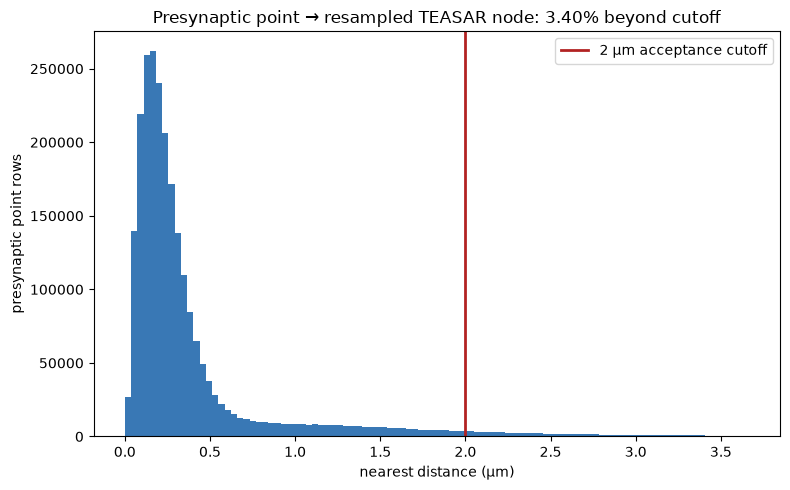

In [2]:
values_um = distances_nm / 1000.
rejected_fraction = np.mean(values_um > 2.)
xmax = max(2.2, min(np.percentile(values_um, 99.5), 20.))
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(values_um, bins=np.linspace(0, xmax, 101), color='#3978b5')
ax.axvline(2., color='#b22222', linewidth=2, label='2 µm acceptance cutoff')
ax.set(title=f'Presynaptic point → resampled TEASAR node: {rejected_fraction:.2%} beyond cutoff',
       xlabel='nearest distance (µm)', ylabel='presynaptic point rows')
ax.legend()
fig.tight_layout()
plt.close(fig)
fig

## Mean distance per cell, colored by cell type

Each dot is one cell, with fixed random horizontal jitter for visibility.
The mean includes all point rows assigned to retained components, including
those beyond 2 µm. Cells with no such rows are listed in the summary but
cannot contribute a mean-distance dot.

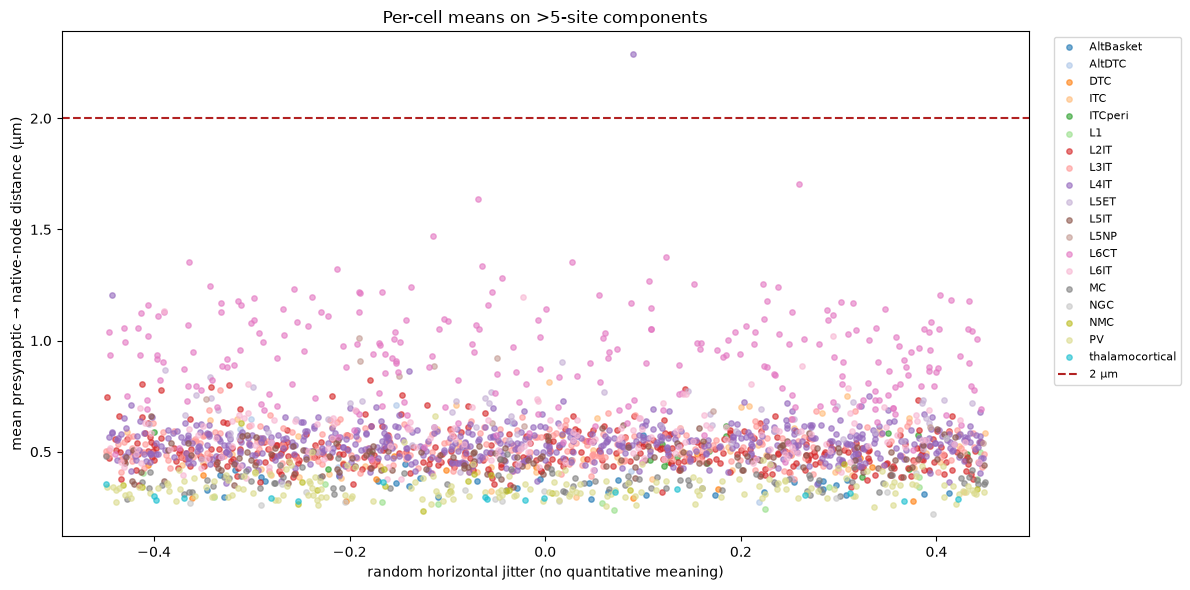

In [3]:
rng = np.random.default_rng(42)
cell_summary['horizontal_jitter'] = rng.uniform(-.45, .45, len(cell_summary))
types = sorted(cell_summary.cell_type.unique())
colors = plt.get_cmap('tab20', max(20, len(types)))
fig, ax = plt.subplots(figsize=(12, 6))
for i, label in enumerate(types):
    group = cell_summary.loc[cell_summary.cell_type.eq(label)]
    ax.scatter(group.horizontal_jitter, group.mean_distance_um,
               s=15, alpha=.6, color=colors(i), label=label)
ax.axhline(2, color='#b22222', linestyle='--', label='2 µm')
ax.set(xlabel='random horizontal jitter (no quantitative meaning)',
       ylabel='mean presynaptic → native-node distance (µm)',
       title='Per-cell means on >5-site components')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
fig.tight_layout()
plt.close(fig)
fig

## Fraction beyond the cutoff by cell type

Pool point rows within each type; this weights cells by the number of eligible
points. Every type uses the same component-selection rule.

,cells,points,beyond_cutoff,retained_components,retained_edges,fraction_beyond_cutoff
cell_type,,,,,,
AltBasket,34,45530,608,96,4237116,0.013354
AltDTC,9,5544,276,29,766423,0.049784
DTC,16,31196,1174,64,2507317,0.037633
ITC,71,45473,2811,131,5839972,0.061817
ITCperi,18,12682,683,31,1273668,0.053856
L1,13,19136,499,26,1242500,0.026077
L2IT,346,154542,6347,921,37321344,0.041070
L3IT,245,145672,6856,607,26634900,0.047065
L4IT,546,368598,18688,1144,54085777,0.050700


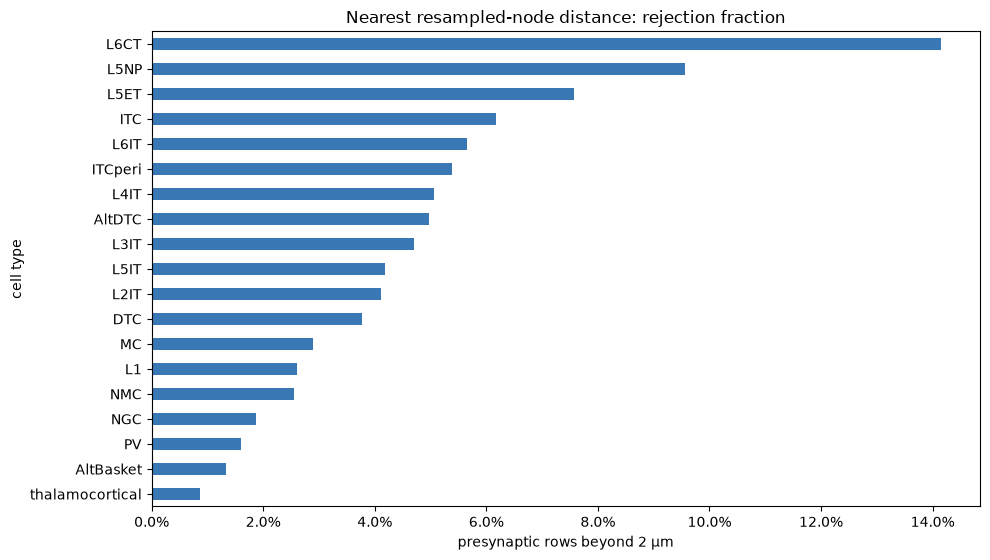

In [4]:
by_type = cell_summary.groupby('cell_type').agg(
    cells=('root_id','size'), points=('n_presynaptic_points','sum'),
    beyond_cutoff=('n_presynaptic_points_over_2um','sum'),
    retained_components=('retained_components','sum'),
    retained_edges=('retained_edges','sum'))
by_type['fraction_beyond_cutoff'] = by_type.beyond_cutoff / by_type.points.replace(0, np.nan)
display(by_type)
fig, ax = plt.subplots(figsize=(10, max(4, .3*len(by_type))))
by_type.fraction_beyond_cutoff.sort_values().plot.barh(ax=ax, color='#3978b5')
ax.xaxis.set_major_formatter(PercentFormatter(1.))
ax.set(xlabel='presynaptic rows beyond 2 µm', ylabel='cell type',
       title='Nearest resampled-node distance: rejection fraction')
fig.tight_layout()
plt.close(fig)
fig

## Cross-checks against the native database metadata

In [5]:
totals = metadata['totals']
assert len(cell_summary) == metadata['n_cells'] == 2209
assert cell_summary.root_id.is_unique
assert len(distances_nm) == cell_summary.n_presynaptic_points.sum()
assert (distances_nm <= 2000).sum() == totals['retained_rows_within_2um']
assert cell_summary.retained_edges.sum() == totals['retained_edges']
assert cell_summary.retained_components.sum() == totals['retained_components']
assert cell_summary.retained_unique_accepted_sites.sum() == totals['retained_unique_accepted_sites']
display(cell_summary.drop(columns='horizontal_jitter').sort_values('mean_distance_um', ascending=False).head(20))
print('All cohort, component, edge, and distance counts match.')

,root_id,cell_type,n_presynaptic_points,mean_distance_um,n_presynaptic_points_over_2um,fraction_presynaptic_points_over_2um,total_components,retained_components,total_edges,retained_edges,retained_unique_accepted_sites
1918,864691136380816597,L4IT,1197,2.287856,129,0.107769,7,3,184078,172923,1068
1710,864691136125985318,L6CT,15,1.705619,4,0.266667,6,1,25109,13088,11
1124,864691135764062006,L6CT,72,1.637757,22,0.305556,8,2,39800,16598,50
633,864691135492274791,L6CT,121,1.469736,34,0.280992,5,2,55238,41773,87
1881,864691136335213235,L6CT,372,1.376020,98,0.263441,7,2,93094,75990,274
349,864691135350420951,L6CT,177,1.353919,47,0.265537,8,4,59633,51901,130
950,864691135688407776,L6CT,105,1.352319,27,0.257143,6,2,43567,35631,78
476,864691135417827770,L6CT,119,1.333845,33,0.277311,5,2,40686,31147,86
2188,864691137021162094,L6CT,115,1.322071,28,0.243478,5,1,48623,25033,87
1832,864691136287879619,L6CT,85,1.280490,23,0.270588,9,2,51766,25926,62


All cohort, component, edge, and distance counts match.
